# Customer Churn Analysis

## Tools
- Python
- Google Colab
- Pandas
- Matplotlib
- Seaborn

## Methodology
CRISP-DM

## Objective
Menganalisis faktor-faktor yang mempengaruhi customer churn dan memberikan rekomendasi bisnis untuk meningkatkan retensi pelanggan.

# Customer Churn Analysis

## Business Understanding

Perusahaan ingin memahami faktor-faktor yang menyebabkan pelanggan berhenti menggunakan layanan (churn).

Tujuan analisis:

1. Mengetahui tingkat churn pelanggan.
2. Mengidentifikasi karakteristik pelanggan yang churn.
3. Memberikan rekomendasi bisnis untuk meningkatkan retensi pelanggan.

In [4]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [5]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Setting Style
sns.set_style("whitegrid")

# Display all columns
pd.set_option('display.max_columns', None)

In [6]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Understanding

Melakukan eksplorasi awal terhadap struktur dan karakteristik dataset.

In [7]:
df.shape

(7043, 21)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Quality Assessment

Memeriksa missing values, tipe data, dan potensi masalah kualitas data.

In [11]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [15]:
df['TotalCharges'].dtype

dtype('O')

## Data Cleaning

Mengubah TotalCharges menjadi numeric dan menangani missing values.

In [17]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [18]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [19]:
missing_rows = df['TotalCharges'].isnull().sum()

print(
    f"Missing values in TotalCharges: {missing_rows}"
)

Missing values in TotalCharges: 11


In [20]:
df.dropna(inplace=True)

In [21]:
df.isnull().sum().sum()

np.int64(0)

Ditemukan 11 data dengan nilai TotalCharges kosong.
Karena jumlahnya sangat kecil dibanding total data (<0.2%),
record tersebut dihapus tanpa memengaruhi hasil analisis secara signifikan.

## Feature Engineering

Mengelompokkan pelanggan berdasarkan lama berlangganan (tenure).

In [22]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=[
        '0-12 Months',
        '13-24 Months',
        '25-48 Months',
        '49-72 Months'
    ]
)

In [23]:
df[['tenure','TenureGroup']].head()

,tenure,TenureGroup
0,1,0-12 Months
1,34,25-48 Months
2,2,0-12 Months
3,45,25-48 Months
4,2,0-12 Months


## Executive KPI Summary

In [24]:
total_customer = len(df)

churn_rate = (
    (df['Churn'] == 'Yes')
    .mean()
    * 100
)

avg_tenure = df['tenure'].mean()

avg_monthly = df['MonthlyCharges'].mean()

print("===== KPI SUMMARY =====")

print(
    f"Total Customers : {total_customer}"
)

print(
    f"Churn Rate      : {churn_rate:.2f}%"
)

print(
    f"Average Tenure  : {avg_tenure:.1f} Months"
)

print(
    f"Average Monthly Charges : ${avg_monthly:.2f}"
)

===== KPI SUMMARY =====
Total Customers : 7032
Churn Rate      : 26.58%
Average Tenure  : 32.4 Months
Average Monthly Charges : $64.80


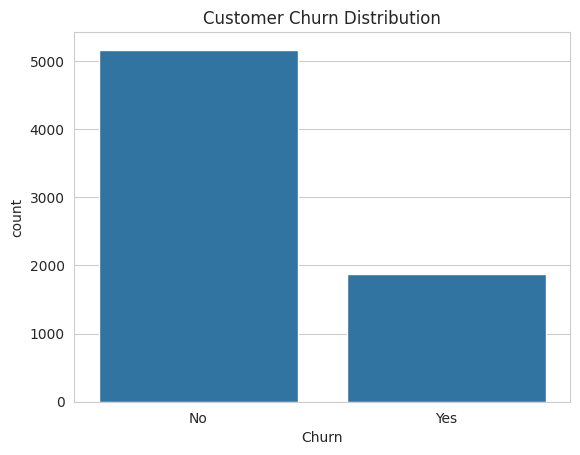

In [25]:
sns.countplot(
    x='Churn',
    data=df
)

plt.title(
    'Customer Churn Distribution'
)

plt.show()

Sebagian besar pelanggan masih bertahan,
namun sekitar seperempat pelanggan telah melakukan churn.

In [26]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


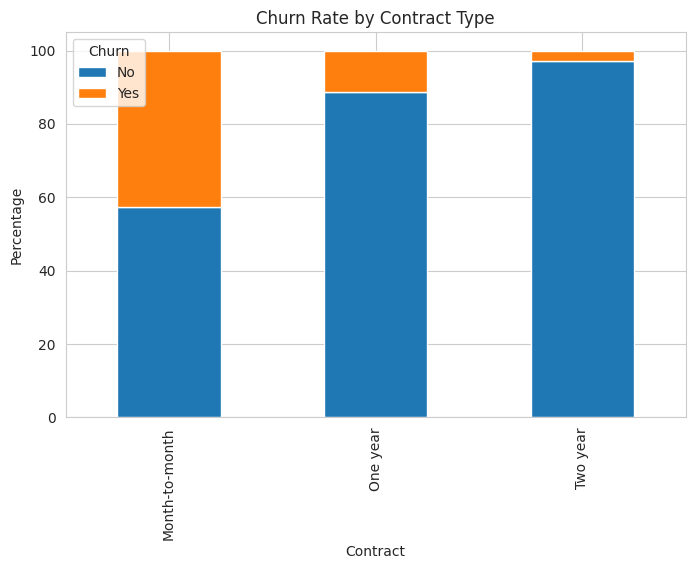

In [27]:
contract_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title(
    'Churn Rate by Contract Type'
)

plt.ylabel('Percentage')

plt.show()

Pelanggan dengan kontrak Month-to-Month memiliki tingkat churn tertinggi.

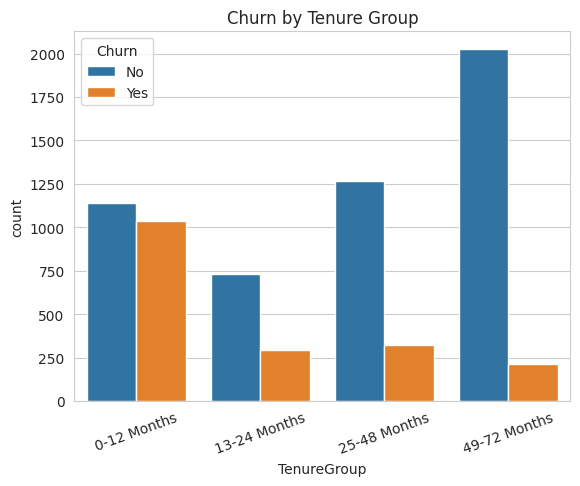

In [28]:
sns.countplot(
    x='TenureGroup',
    hue='Churn',
    data=df
)

plt.title(
    'Churn by Tenure Group'
)

plt.xticks(rotation=20)

plt.show()

Pelanggan baru lebih rentan melakukan churn dibanding pelanggan lama.

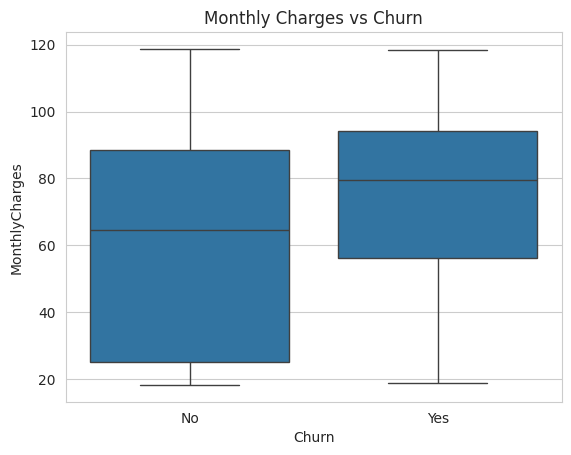

In [29]:
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title(
    'Monthly Charges vs Churn'
)

plt.show()

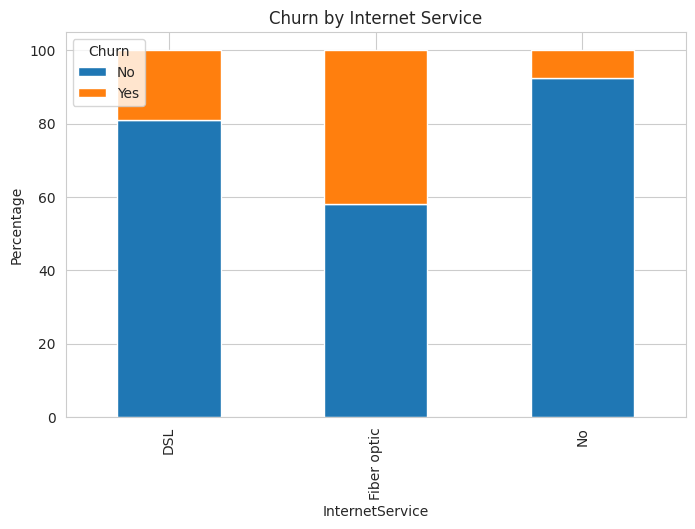

In [30]:
internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

internet_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title(
    'Churn by Internet Service'
)

plt.ylabel('Percentage')

plt.show()

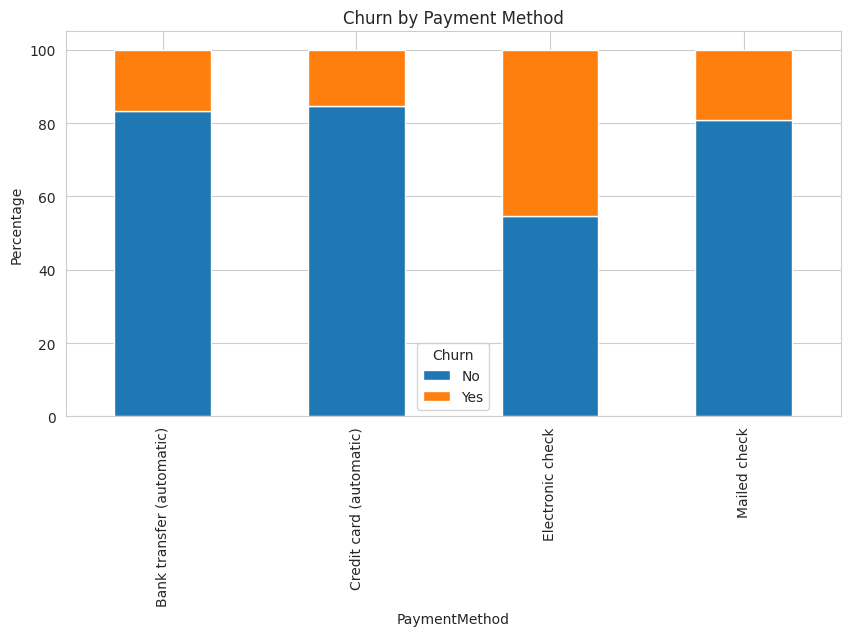

In [31]:
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

payment_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(10,5)
)

plt.title(
    'Churn by Payment Method'
)

plt.ylabel('Percentage')

plt.show()

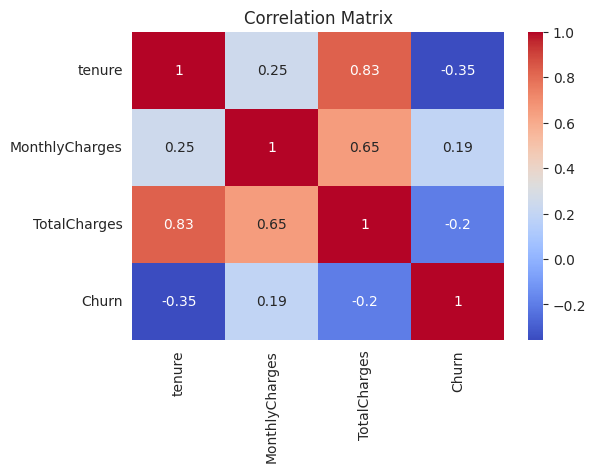

In [32]:
temp = df.copy()

temp['Churn'] = temp['Churn'].map({
    'No':0,
    'Yes':1
})

corr = temp[
    [
        'tenure',
        'MonthlyCharges',
        'TotalCharges',
        'Churn'
    ]
].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title(
    'Correlation Matrix'
)

plt.show()

## Business Recommendations

1. Mendorong pelanggan Month-to-Month beralih ke kontrak tahunan.
2. Membuat program onboarding untuk pelanggan baru.
3. Meninjau struktur harga layanan premium.
4. Menawarkan promosi retensi sebelum pelanggan memasuki bulan ke-6.

# 📊 Executive Dashboard

Ringkasan metrik utama Customer Churn.

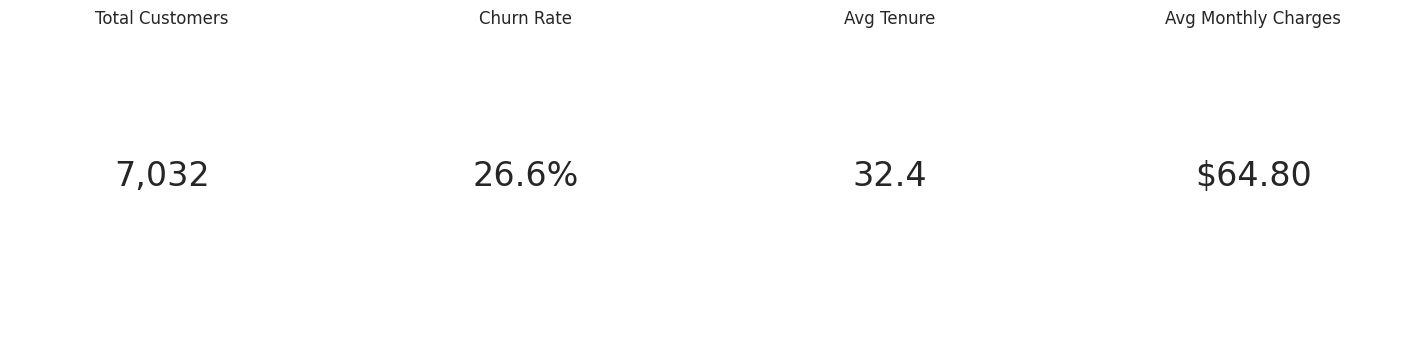

In [33]:
fig, ax = plt.subplots(
    1,
    4,
    figsize=(18,4)
)

ax[0].text(
    0.5,
    0.5,
    f"{len(df):,}",
    fontsize=24,
    ha='center'
)

ax[0].set_title("Total Customers")
ax[0].axis('off')

ax[1].text(
    0.5,
    0.5,
    f"{churn_rate:.1f}%",
    fontsize=24,
    ha='center'
)

ax[1].set_title("Churn Rate")
ax[1].axis('off')

ax[2].text(
    0.5,
    0.5,
    f"{avg_tenure:.1f}",
    fontsize=24,
    ha='center'
)

ax[2].set_title("Avg Tenure")
ax[2].axis('off')

ax[3].text(
    0.5,
    0.5,
    f"${avg_monthly:.2f}",
    fontsize=24,
    ha='center'
)

ax[3].set_title("Avg Monthly Charges")
ax[3].axis('off')

plt.show()

# Business Insights

### Insight 1

Month-to-Month customers memiliki churn rate tertinggi dibanding pelanggan dengan kontrak tahunan maupun dua tahunan.

### Insight 2

Pelanggan dengan tenure kurang dari 12 bulan merupakan kelompok yang paling rentan melakukan churn.

### Insight 3

Pelanggan dengan Monthly Charges yang lebih tinggi cenderung memiliki probabilitas churn yang lebih besar.

### Insight 4

Layanan Fiber Optic menunjukkan tingkat churn yang lebih tinggi dibandingkan pelanggan DSL.

In [34]:
print("="*50)
print("PROJECT SUMMARY")
print("="*50)

print(f"Total Customers : {len(df)}")
print(f"Churn Rate      : {churn_rate:.2f}%")

print("\nKey Findings:")
print("- Month-to-Month contracts drive churn")
print("- New customers are more likely to churn")
print("- Higher monthly charges increase churn risk")

print("\nRecommended Actions:")
print("- Promote annual contracts")
print("- Improve onboarding process")
print("- Optimize premium pricing")

PROJECT SUMMARY
Total Customers : 7032
Churn Rate      : 26.58%

Key Findings:
- Month-to-Month contracts drive churn
- New customers are more likely to churn
- Higher monthly charges increase churn risk

Recommended Actions:
- Promote annual contracts
- Improve onboarding process
- Optimize premium pricing


# **PROJECT SUMMARY**

Total Customers : 7032
Churn Rate      : 26.58%

Key Findings:
- Month-to-Month contracts drive churn
- New customers are more likely to churn
- Higher monthly charges increase churn risk

Recommended Actions:
- Promote annual contracts
- Improve onboarding process
- Optimize premium pricing